In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Load in the data

In [3]:
# Coarse (multiple sheets)
dfs_coarse = pd.read_excel("data/BAAD_Insurgency_1998-2015_Release_1.xlsx",
                    sheet_name=['Organization List', 'State List', 'Organizational Inferences', 'Network Org-Org', 'Network State-Org'])

# Fine
# df_fine = pd.read_excel("data/globalterrorismdb_0522dist.xlsx")

/home/jc820/Documents/academic/PhD_research/sandia/sandia_venv/lib/python3.10/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)


### Create basic network structures

In [4]:
## Create the organisation-Organisation network
df_uniques = dfs_coarse['Network Org-Org'].drop_duplicates()
all_torgs = list(set(df_uniques['SIDCODE'].to_list() + 
                     df_uniques['RIDCODE'].to_list()))

# Node mapping dictionary as "torg: index"
torg_mapping_dict = {value: index for index, value in enumerate(all_torgs)}

# Network dataframe
network_org_org = pd.DataFrame(columns=['node_out', 'node_in', 'year', 'affiliation', 'ideological', 'material'])
network_org_org[['year', 'affiliation', 'ideological', 'material']] = (
    df_uniques[['YEAR', 'AFFLIATN', 'IDEOLGCL', 'MATERIAL']]
)
network_org_org['node_out'] = df_uniques['SIDCODE'].map(torg_mapping_dict)
network_org_org['node_in'] = df_uniques['RIDCODE'].map(torg_mapping_dict)


# ## State-Organisation information
# df_uniques = dfs_coarse['Network State-Org'].drop_duplicates()
# df_state_org = pd.DataFrame(columns=['state', 'node_in', 'year', 'affiliation', 'material'])
# df_state_org['state'] = df_uniques['SEND']
# df_state_org['node_in'] = df_uniques['RIDCODE'].map(torg_mapping_dict)
# df_state_org[['year', 'affiliation', 'material']] = (
#     df_uniques[['YEAR', 'AFFLIATN', 'MATERIAL']]
# )
# # Drop node_in values that are NaN as they don't appear in network_org_org
# df_state_org.dropna(subset=['node_in'], inplace=True)

In [1]:
network_org_org

NameError: name 'network_org_org' is not defined

### Filter the fine data

In [148]:
# Separate data based on earliest and lastest entry in dfs_coarse
pre_1998_bool = df_fine['iyear'] < 1998
post_2015_bool = df_fine['iyear'] > 2015
df_fine_filt = df_fine.loc[(~pre_1998_bool) & (~post_2015_bool)].reset_index(drop=True)

# Extract relevant columns
df_fine_filt = df_fine_filt[['iyear', 'imonth', 'iday', 'country_txt',
                             'region', 'latitude', 'longitude',
                             'crit1', 'crit2', 'crit3',
                             'attacktype1', 'attacktype2', 'attacktype3',
                             'success', 'suicide',
                             'weaptype1', 'weapsubtype1', 
                             'weaptype2', 'weapsubtype2',
                             'weaptype3', 'weapsubtype3',
                             'weaptype4', 'weapsubtype4',
                             'targtype1', 'targsubtype1', 'natlty1',
                             'gname', 'gname2', 'gname3',
                             'guncertain1', 'guncertain2', 'guncertain3',
                             'individual', 
                             'nkill', 'nwound', 'property', 'ishostkid',
                             'ransom', 'INT_LOG', 'INT_IDEO', 'INT_MISC']]

# Map gname, gname2 and gname3 to TORG from coarse data
gname_to_TORG_mapping_dict = (
    dfs_coarse['Organization List'].set_index('GROUP')['TORG'].to_dict()
)
df_fine_filt['gname'] = df_fine_filt['gname'].map(gname_to_TORG_mapping_dict)
df_fine_filt['gname2'] = df_fine_filt['gname2'].map(gname_to_TORG_mapping_dict)
df_fine_filt['gname3'] = df_fine_filt['gname3'].map(gname_to_TORG_mapping_dict)
df_fine_filt.dropna(subset=['gname', 'gname2', 'gname3'], 
                    how='all', inplace=True)
df_fine_filt['gname'] = df_fine_filt['gname'].map(torg_mapping_dict)
df_fine_filt['gname2'] = df_fine_filt['gname2'].map(torg_mapping_dict)
df_fine_filt['gname3'] = df_fine_filt['gname3'].map(torg_mapping_dict)



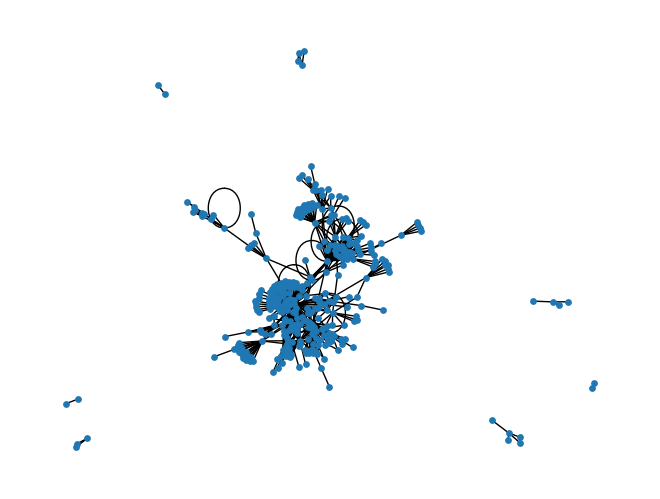

In [12]:
import networkx as nx

G = nx.from_pandas_edgelist(
    network_org_org,
    source='node_out',
    target='node_in'
)

nx.draw(G, node_size=15)

plt.show()